# The Cushing Glut 🛢️
### Brent and WTI are the same oil in two places. Until the tanks in Oklahoma filled up.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Traders have long faded the gap between the world's two benchmark crudes: same light sweet
oil, so the price difference should be about the cost of shipping it, and any stretch should
snap back. For twenty-three years of this tape it nearly did. Then, in 2010-09, the
gap found a new home about $9 a barrel away, and anyone who kept fading it
back to the old one spent most of a decade underwater.

> 📓 **This is the plain-language layer.** The unit-root tests, the break bootstrap and the
> power study are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** The prices here are **spot, monthly averages** — you cannot
> trade them. A real trade uses futures and pays a monthly roll, so every profit shown is an
> **upper bound**.

## Beat 0 · The verdict (real tape)

| | Stamp | In one line |
|---|---|---|
| **Signal** | **Weak** | the gap *was* tethered — reverting with a half-life of about 2.7 months — then a data-chosen break in 2010-09 moved its home; across the whole sample it is not tethered |
| **Tradability** | **Mirage** | fading it in real time earned +0.94% a year after costs (t = +0.84) on prices nobody can trade; the trader who learned the tether before 2010 was underwater 114 months |

*Numbers from [`docs/results.md`](../docs/results.md) (as-of 2020-01-31, fingerprint
`4563b3235b4e`); the charts below are recomputed live from the same pinned tape.*

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
BLUE, RED, GREEN, GREY, AMBER = "#1f6feb", "#c0392b", "#2ea44f", "#8b949e", "#b08800"
from cushing import data, strategy as st
px = data.load_crude()
sf = st.spread_frame(px)
print(f"real tape: arch crude, {len(px)} months {px.index[0]:%Y-%m} → {px.index[-1]:%Y-%m}, "
      f"as-of {data.AS_OF}, fingerprint {data.fingerprint(px)}")

real tape: arch crude, 393 months 1987-05 → 2020-01, as-of 2020-01-31, fingerprint 4563b3235b4e


## 1 · The claim

> *"Brent and WTI are the same commodity in two places. The spread is tethered by transport
> cost and always mean-reverts — fade it when it stretches."*

It is a good claim. Both are light, sweet crudes that refineries can largely swap. If WTI
gets too cheap, someone buys it, ships it and sells it as Brent-priced oil; if Brent gets too
cheap, the reverse. That physical arbitrage is the rubber band.

## 2 · So what?

If it were true, it would be one of the cleanest trades in commodities: a bet on two
near-identical barrels converging, with no view on the price of oil itself. It would also
say something comforting about markets — that physical arbitrage keeps prices honest.

The catch the claim skips: the rubber band is only as strong as the *pipes*. Arbitrage needs
somewhere to move the oil. Cushing, Oklahoma — where WTI is delivered — is a landlocked tank
farm. When US shale output surged around 2010 faster than pipelines out of Cushing were built,
the oil had nowhere to go.

## 3 · How we'd know

Before running anything we wrote down what would count:

- **Tethered "always"** means the gap is stationary over the *whole* sample, there is no
  significant break in its average level, and a fader using only past data makes money with a
  robust t-statistic of at least 2.
- **Tethered within a regime** would mean a significant break, with the gap stationary before it.
- **Tradable** needs the real-time fader to survive costs (t ≥ 2) *and* the trader who
  calibrated on pre-2010 data to recover within three years.

The break date is **found by the data** (a scan over every possible month), not picked by hand.

## 4 · The teardown

### 4.1 The gap, month by month

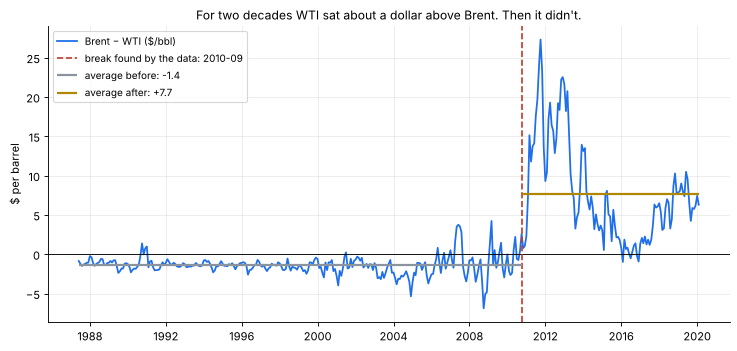

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(sf.index, sf["spread"], color=BLUE, lw=1.6, label="Brent − WTI ($/bbl)")
ax.axhline(0, color="k", lw=0.8)
b = st.sup_f_mean(sf["log_ratio"])
ax.axvline(b["break_date"], color=RED, ls="--", lw=1.5,
           label=f"break found by the data: {b['break_date']:%Y-%m}")
pre = sf["spread"][sf.index < b["break_date"]].mean()
post = sf["spread"][sf.index >= b["break_date"]].mean()
ax.hlines(pre, sf.index[0], b["break_date"], color=GREY, lw=2, label=f"average before: {pre:+.1f}")
ax.hlines(post, b["break_date"], sf.index[-1], color=AMBER, lw=2, label=f"average after: {post:+.1f}")
ax.set_ylabel("$ per barrel"); ax.legend(fontsize=9, loc="upper left")
ax.set_title("For two decades WTI sat about a dollar above Brent. Then it didn't.", fontsize=11)
plt.show()

Before the break, WTI usually traded a little **above** Brent (about $1.4 on average).
After it, Brent sat about **$7.7 above** WTI on average, peaking near $27.31 in
2011-09. The gap still wiggled and snapped back — around a *different* centre.

> 🔬 **For the quants.** The break comes from a sup-F scan for a single mean shift, with a
> bootstrap p-value of 0.002 against a persistent, break-free AR(1) — the textbook
> critical values are far too lenient for a series this sticky.

### 4.2 How fast did it snap back?

In [3]:
hl = st.halflife_by_regime(sf["log_ratio"], [b["break_date"]])
show = hl[["start", "end", "n", "halflife", "halflife_lo", "halflife_hi"]].copy()
show["start"] = show["start"].dt.strftime("%Y-%m"); show["end"] = show["end"].dt.strftime("%Y-%m")
show.columns = ["from", "to", "months", "half-life (months)", "low", "high"]
show

,from,to,months,half-life (months),low,high
0,1987-05,2010-08,280,2.696,1.927,4.226
1,2010-09,2020-01,113,4.162,2.392,12.201


A **half-life** is how long it takes for half of a stretch to disappear. Before the break,
about 2.7 months — a fast rubber band. After it, about 4.2 months around
the new level, with a much wider range of uncertainty. Inside each era, the claim looks
fine. The problem is the jump between them.

### 4.3 What the fader actually lived through

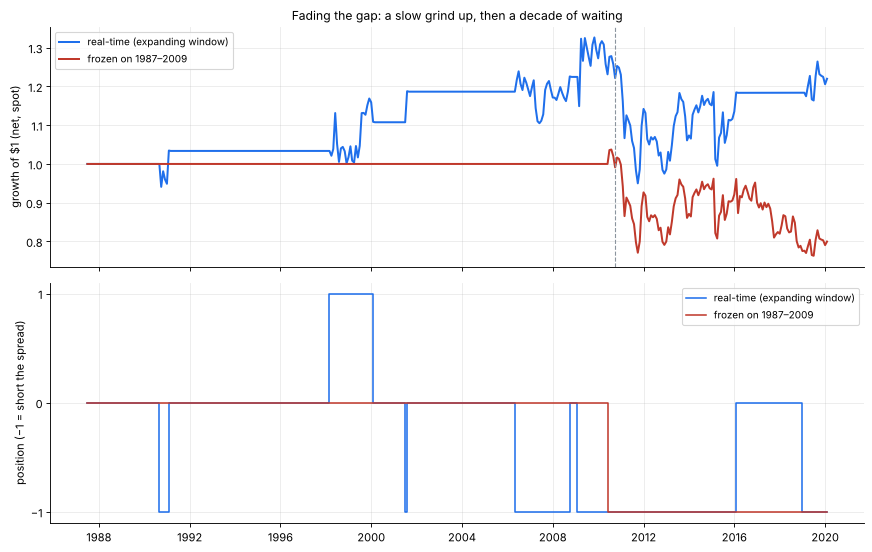

In [4]:
rules = {"real-time (expanding window)": st.zscore_realtime(sf["log_ratio"]),
         "frozen on 1987–2009": st.zscore_frozen(sf["log_ratio"])}
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for (name, z), col in zip(rules.items(), (BLUE, RED)):
    bk = st.book(px, st.positions(z))
    eq = (1 + bk["net"]).cumprod()
    axes[0].plot(eq.index, eq, color=col, lw=1.8, label=name)
    axes[1].plot(bk.index, bk["pos"], color=col, lw=1.4, drawstyle="steps-post", label=name)
axes[0].axvline(b["break_date"], color=GREY, ls="--", lw=1)
axes[0].set_ylabel("growth of $1 (net, spot)"); axes[0].legend(fontsize=9)
axes[1].set_ylabel("position (−1 = short the spread)"); axes[1].set_yticks([-1, 0, 1])
axes[1].legend(fontsize=9)
axes[0].set_title("Fading the gap: a slow grind up, then a decade of waiting", fontsize=11)
plt.tight_layout(); plt.show()

Both traders bet that the gap would close — "short the spread" means betting Brent falls back
toward WTI. The real-time trader was already short from 2009-01 and, at the worst
point (2011-09), was down **−22.4%** of the money behind the trade, or about
**$25.6 a barrel**. The trader who learned the "normal" gap on 1987–2009 data
went short in 2010-05 and was **still underwater 114 months later**
when the tape ends — the gap never went back to its old home.

## 5 · The verdict

**Signal: Weak.** The rubber band was real *within* each era — before 2010-09
the gap reverted with a 2.7-month half-life — but the claim says *always*, and over the
whole tape the gap is not stationary (ADF p = 0.45). A data-found break moved the
gap's centre by about $9. Fading it in real time earned a gross t of
+1.12, short of the desk's bar of 2.

**Tradability: Mirage.** After costs the real-time fader made +0.94% a year
(Sharpe +0.12, t = +0.84) — and that is on spot prices that can't be traded, so
it is the *best case*. The pre-2010 believer lost about 23.7% at the worst and
never got back to even.

## 6 · Could you trade it?

Not as stated. A real trader holds ICE Brent and NYMEX WTI **futures** and rolls them every
month. During the glut, WTI futures were in steep *contango* (later months dearer than the
front), so being long WTI — the side the fader takes — meant **paying** to roll on top of the
losses above. The spot tape cannot see that cost, which is why the numbers here are an upper
bound. A rolling 60-month window adapts faster (gross t +2.09), but picking the
window that worked after the fact is not a strategy.

## 7 · Going further 🚪

- **Use the futures.** Rebuild the trade on rolled ICE Brent / NYMEX WTI contracts and charge
  the actual roll yield — the number most likely to make the post-2010 loss worse.
- **Watch the pipes.** The gap's home is set by transport capacity: Seaway's reversal (2012),
  the 2015 end of the US crude-export ban, new Gulf Coast pipelines. A model that moves the
  mean with infrastructure, not a fixed z-score, is the honest version of the claim.
- **Fork it:** change the entry/exit bands or the window in `cushing/strategy.py` and re-run
  `examples/verify.py` — and remember that trying many and reporting the best is the trap.